In [1]:
# Importing needed code

from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import statistics as stat

from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier, bimodal
from data_processing.reporting.plotting import plot_fom, plot_scatter

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.signal import savgol_filter

# Load Data

In [6]:
# Location of PSD data folder; change as needed
PARQ_ROOT = Path("C:/Users/User/Desktop/FOM Analysis/UBC Background 20221214-19/psd")

False

In [8]:
# Load PSD data to "psd_report" DataFrame
psd_report = pd.read_parquet(PARQ_ROOT, columns=["CALIB_ENERGY","ENERGYSHORT", "ENERGY", "TIMETAG"])
psd_report = psd_report.astype({"CALIB_ENERGY": float, "ENERGYSHORT": int, "ENERGY": int, "TIMETAG": np.int64})

# Calculate PSD value as new column "tail / total"
psd_report["tail / total"] = (psd_report["ENERGY"] - psd_report["ENERGYSHORT"]) / psd_report["ENERGY"]
psd_report = psd_report.dropna()
psd_report = psd_report[psd_report["tail / total"].between(0,0.5)]
psd_report.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\FOM Analysis\\UBC Background 20221214-19\\psd'

In [9]:
# Generate random sample of "psd_report" for graphing
# Graphing 300M points is way too slow, so best to graph a reasonable fraction of all points

sample_frac = 0.1  # fraction of points to put in sample (0-1)
random_state = 1323  # random number generator seed; change to try different samples

graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

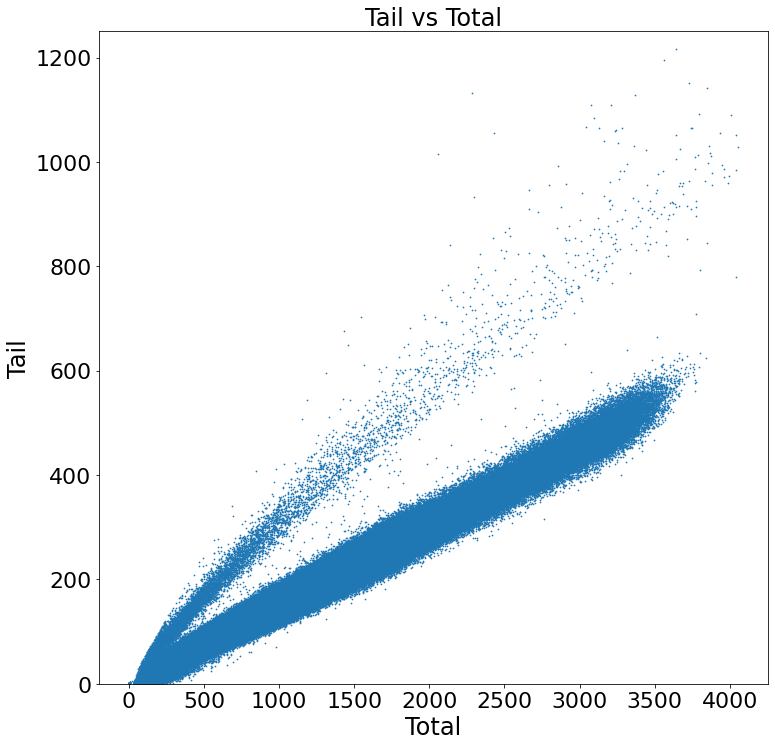

In [11]:
# Graph tail vs total scatterplot (optional, but helps diagnose data issues)

fontsize = 24
label_size = 22

fig, ax = plt.subplots(figsize=(12,12))

ax.scatter(
    graph_sample["ENERGY"], graph_sample["ENERGY"] - graph_sample["ENERGYSHORT"], s=0.5
)

ax.set_ylim(0,1250)
ax.set_ylabel("Tail", fontsize=fontsize)
ax.set_xlabel("Total", fontsize=fontsize)
ax.set_title("Tail vs Total", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=label_size)
ax.tick_params(axis='both', which='minor', labelsize=label_size)

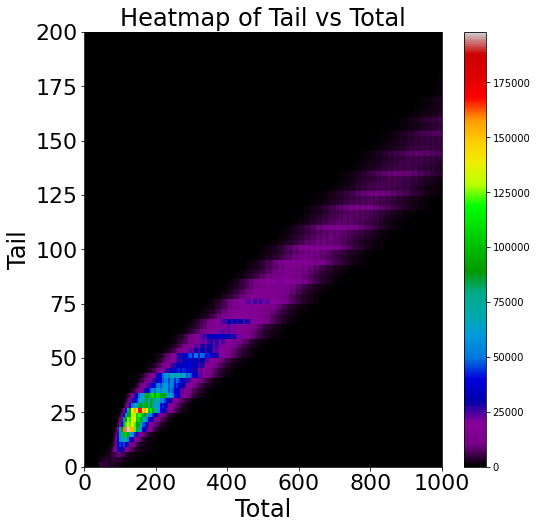

In [12]:
# Graph tail vs total heatmap (also optional)

resolution = (720, 720)

x_tt, y_tt = psd_report["ENERGY"], psd_report["ENERGY"] - psd_report["ENERGYSHORT"]
Z_tt, xe_tt, ye_tt = np.histogram2d(x_tt, y_tt, resolution)

# generating psd/energy 2D histogram
fig, ax = plt.subplots(figsize=(8,8))
cmap = plt.colormaps["nipy_spectral"]
pcm = ax.pcolormesh(xe_tt, ye_tt, Z_tt.T, cmap=cmap)

fontsize = 24
ax.set_xlim(0,1e3)
ax.set_ylim(0,200)
ax.set_title("Heatmap of Tail vs Total", fontsize=fontsize)
ax.set_ylabel("Tail", fontsize=fontsize)
ax.set_xlabel("Total", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)
fig.colorbar(pcm, ax=ax)

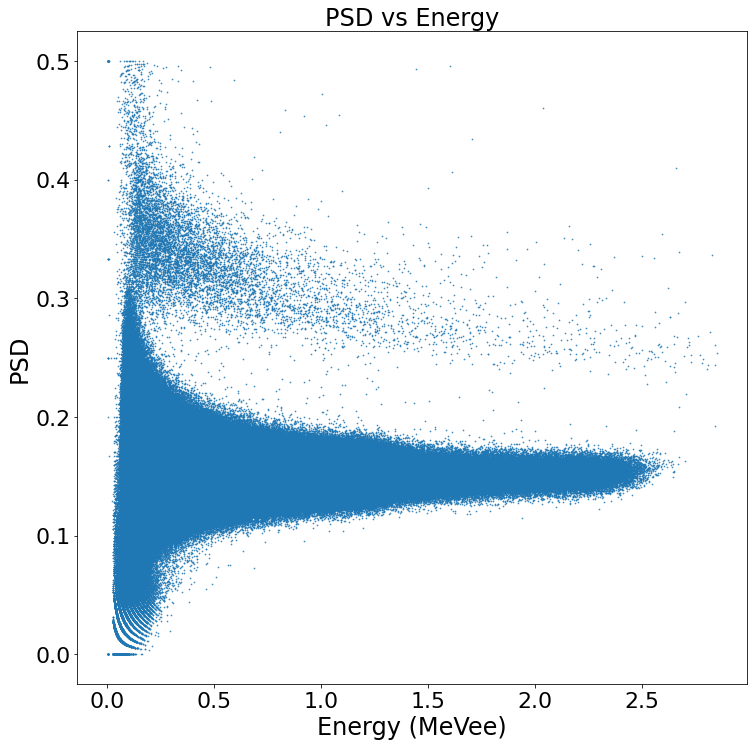

In [13]:
# Graph PSD vs Energy scatterplot

fig, ax = plt.subplots(figsize=(12,12))

ax.scatter(
    graph_sample["CALIB_ENERGY"], graph_sample["tail / total"], s=0.5, alpha=0.8
)

ax.set_ylabel("PSD", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
ax.set_title("PSD vs Energy", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=label_size)
ax.tick_params(axis='both', which='minor', labelsize=label_size)

## Heatmap & Histograms

In [14]:
# Create 2D histogram of PSD vs Energy data
# Generates 2D grid of "bins

resolution = int(1024/2)

x, y = psd_report["CALIB_ENERGY"], psd_report["tail / total"]
Z, xe, ye = np.histogram2d(x, y, resolution)

In [16]:
# Find energy slice width
energy_slice_width = xe[2] - xe[1]
f"Energy Slice Width = {energy_slice_width:.4f} MeVee"

'Energy Slice Width = 0.0056 MeVee'

NameError: name 'xe' is not defined

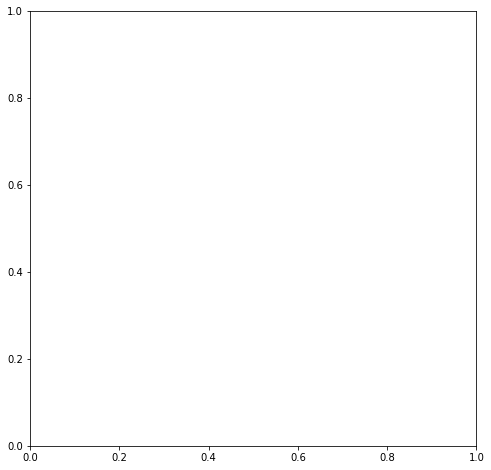

In [4]:
# Graph heatmap of 2D histogram
fig, ax = plt.subplots(figsize=(8,8))
cmap = plt.colormaps["nipy_spectral"]
pcm = ax.pcolormesh(xe, ye, Z.T, cmap=cmap)

fontsize = 24
ax.set_xlim(xe[0],1.5)
ax.set_title("Heatmap of Counts", fontsize=fontsize)
ax.set_ylabel("PSD", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)
fig.colorbar(pcm, ax=ax)

NameError: name 'xe' is not defined

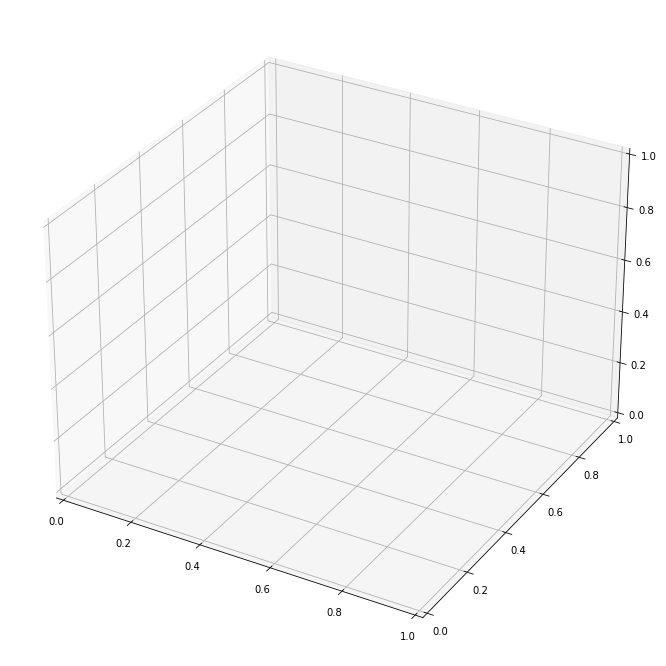

In [3]:
# Graph 2D histogram as 3D contour plot (like a geographic height map)
# Allows view of the entire dataset's "shape"
contour_res = 60  # number of contour lines to use
angle_elev = 55  # Elevation angle (-90=underneath, 0=side, 90=above)
angle_rot = 0  # Rotation angle (0=down X (energy) axis, + rotates clockwise)
log_mode = True  # Graph dataset using log counts (useful for small neutron counts)

fig = plt.figure(figsize=(12,12))
ax = plt.axes(projection='3d')

x, y = np.meshgrid(xe[:-1], ye[:-1])

ax.view_init(angle_elev, angle_rot)
if log_mode:
    ax.contour3D(x, y, np.log10(Z.T+1), contour_res, cmap=cmap)
else:
    ax.contour3D(x, y, Z.T, contour_res, cmap=cmap)

# ax.plot_surface(x, y, Z.T, cmap=cmap, antialiased=True)
# ax.zaxis.set_major_locator(ticker.LogLocator())

# ax.contour([0.35, 0.35], [0, 0], [100, 100])
ax.set_title("PSD Histogram", fontsize=16)
ax.set_ylabel("PSD", fontsize=16)
ax.set_xlabel("Energy (MeVee)", fontsize=16)
ax.set_zlabel("Log Counts", fontsize=16)
# ax.set_zticklabels(range(0,1000))
# ax.vlines(0.35, 0, 100)
# ax.set_zscale("log")
# ax.set_zlim(0,10**3)

# FOM Analysis

In [18]:
# FOM function definition

BimodalParams = tuple[float, float, float, float, float, float]
GaussianParams = tuple[float, float, float]
BimodalBounds = tuple[BimodalParams, BimodalParams]

def split_params(
    params: BimodalParams
) -> tuple[GaussianParams, GaussianParams]:
    """Separates bimodal function parameters into 2 sets, one per component gaussian
    
    Parameters
    ----------
    params: BimodalParams
        parameters of a bimodal function
        
    Returns
    -------
    lower_gaussian_params: GaussianParams
        parameters of the lower gaussian (i.e. lower mu value)
    upper_gaussian_params: GaussianParams
        parameters of the upper gaussian (i.e. higher mu value)
    """
    params = abs(params)
    return params[0:3], params[3:]

def get_bimodal_fit(
    bins: np.ndarray, 
    histogram_slice: np.ndarray, 
    bounds: BimodalBounds
) -> tuple[GaussianParams, GaussianParams, np.ndarray]:
    """Fits a histogram slice to a bimodal distribution
    
    Parameters
    ----------
    bins: ndarray
        lower bounds of each PSD bin in the histogram
    histogram_slice: ndarray
        slice of the 2D PSD/Energy histogram taken for a specific energy (i.e. PSD vs Counts)
    bounds: BimodalBounds
        lower and upper bounds of fit parameters for this slice
        
    Returns
    -------
    gamma_params: GaussianParams
        parameters of the gaussian fit for gamma rays
    neutron_params: GaussianParams
        parameters of the gaussian fit for neutrons
    cov: ndarray
        estimated covariance of all bimodial parameters
    """
    params, cov = curve_fit(
        bimodal,
        bins,
        histogram_slice,
        bounds=bounds,
    )
    
    gamma_params, neutron_params = split_params(params)
    
    return gamma_params, neutron_params, cov


def scan_histogram_slices(
    bins: np.ndarray, 
    histogram: np.ndarray, 
    default_bounds: BimodalBounds,
    bounds: list[tuple[tuple[int, int], BimodalBounds]] | None = None, 
    start_idx: int = 0, 
    end_idx: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Determines bimodal fit and FOM for every energy slice in 2D PSD/Energy histogram
    
    Parameters
    ----------
    bins: ndarray
        lower bounds of each PSD bin in the histogram
    histogram: ndarray
        2D PSD/Energy histogram
    default_bounds: BimodalBounds
        default lower and upper bounds of fit parameters
    bounds: list[tuple[tuple[int, int], BimodalBounds]] | None, default None
        allows custom bounds for slice ranges. 
        Each list entry must have a tuple of start and stop indexes, and corresponding fit bounds.
        Bounds are used when the slice index falls within the start/stop range (start inclusive, stop exclusive).
        If index ranges overlap, the last matching range is used.
        If bounds is None, only default_bounds are used.
    start_idx: int, default 0
        starting index (inclusive) of slice range to fit to bimodal
    end_idx: int | None, default None
        ending index (exclusive) of slice range to fit to bimodal
        
    Returns
    -------
    fit_dataframe: DataFrame
        DataFrame of fit parameters including FOM (as columns) for each slice (as rows)
    error_dataframe: DataFrame
        DataFrame of (1 standard deviation) errors in fit parameters (as columns) for each slice (as rows)
    """
    end_idx = len(histogram) if end_idx is None else min(len(histogram), end_idx)
        
    slice_params = []
    slice_err = []
    
    for i in range(start_idx, end_idx):
        fit_bounds = default_bounds
        
        if bounds is not None :
            for i_range, bound in bounds:
                if i in range(*i_range):
                    fit_bounds = bound
        
#         print(f"default = {default_bounds}\nbounds={bounds}")
        gamma_params, neutron_params, cov = get_bimodal_fit(bins, histogram[:,i], fit_bounds)
        
        fom = FOM(*gamma_params[:-1], *neutron_params[:-1])
        
        perr = np.sqrt(np.diag(cov))
    
        slice_params.append((i, *gamma_params, *neutron_params, fom))
        slice_err.append((i, *perr))
    
    columns = ['i', 'mu1', 'sigma1', 'a1', 'mu2', 'sigma2', 'a2']
    df = pd.DataFrame(slice_params, columns=columns + ['fom'])
    err_df = pd.DataFrame(slice_err, columns=columns)
    
    return df, err_df

In [19]:
# Scan 2D histogram's energy slices and get bimodal fit

psd_bin_lbs = ye[:-1]

# Default
default_bounds = (
    (0.1, 0.01, 1, 
     0.25, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.38, 0.04, 2000)
)

bounds_a = (
    (0.1, 0.01, 1, 
     0.35, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.04, 2000)
)

bounds_b = (
    (0.1, 0.01, 1, 
     0.34, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.03, 2000)
)


# Ranged Example
bounds = [
    ((0,60), bounds_a),
]

start_scan_idx = 0
end_scan_idx = 420

end_scan_idx = min(end_scan_idx, len(Z))

# df_fom = find_threshold_fom_slice(psd_bin_lbs, Z.T, bounds, 0, end_scan_idx)

df, df_err = scan_histogram_slices(
    psd_bin_lbs, 
    Z.T,
    bounds=bounds,
    default_bounds=default_bounds, 
    start_idx = start_scan_idx, 
    end_idx = end_scan_idx
)


df.head()

,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
0,0,0.166016,0.01,1.000000,0.350000,0.04,1.216627e+00,1.562614
1,1,0.149996,0.01,1.000000,0.353878,0.01,1.011148e-04,4.329050
2,2,0.149997,0.01,1.000000,0.352159,0.01,5.004890e-05,4.292522
3,3,0.123305,0.01,1.000000,0.352159,0.01,4.912010e-08,4.859275
4,4,0.100000,0.10,13.881088,0.360000,0.01,5.558638e-15,1.003744


In [22]:
# Find energy slices with FOM between 1.2 and 1.3 (energy cutoff area of interest)

fom_slice = df.query("(1.2 < fom) & (fom <= 1.3)")
fom_slice

,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
7,7,0.100000,0.081908,79.541363,0.36,0.01,0.045617,1.201328
28,28,0.156874,0.027737,9140.279547,0.35,0.04,14.832375,1.210761
29,29,0.156800,0.027270,8888.565281,0.35,0.04,14.156545,1.219631
30,30,0.156708,0.026718,8680.069759,0.35,0.04,13.217794,1.230306
31,31,0.156523,0.026283,8476.208864,0.35,0.04,13.166235,1.239567
32,32,0.156450,0.025727,8290.270074,0.35,0.04,13.033753,1.250518
33,33,0.156199,0.025327,8088.111743,0.35,0.04,12.573482,1.259818
34,34,0.156089,0.024962,7868.129893,0.35,0.04,12.530625,1.267607
35,35,0.155966,0.024563,7718.302916,0.35,0.04,12.572387,1.276246
36,36,0.155833,0.024186,7570.987229,0.35,0.04,12.423299,1.284631


In [24]:
# Manually find FOM threshold slice (number is index of first slice past threshold)

fom_slice = fom_slice.loc[35,:]
slice_idx = int(fom_slice["i"])

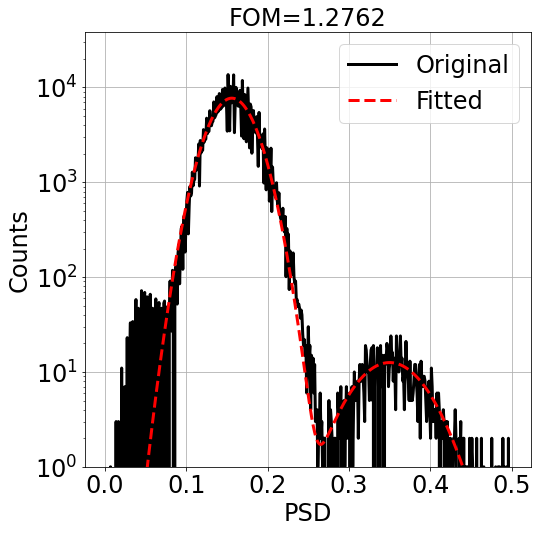

In [25]:
# Graph FOM threshold slice
# histogram_slice = Z.T[:,int(fom_slice["i"])]
# params = fom_slice[1:-1]
# fom = fom_slice["fom"]

# fig, ax = plt.subplots(figsize=(8,8))
# ax.plot(psd_bin_lbs, histogram_slice, "k", lw=3, label="Original")
# ax.plot(psd_bin_lbs, bimodal(psd_bin_lbs, *params), 'r--', lw=3, label="Fitted")

# ax.set_yscale("log")
# ax.set_ylim(1)
# gamma_params, neutron_params = split_params(params)

# ax.set_title(f"FOM={fom:.4f}", fontsize=fontsize)
# ax.set_ylabel("Counts", fontsize=fontsize)
# ax.set_xlabel("PSD", fontsize=fontsize)
# ax.legend(fontsize=fontsize)
# ax.tick_params(axis='both', which='major', labelsize=fontsize)
# ax.tick_params(axis='both', which='minor', labelsize=fontsize)
# ax.grid()

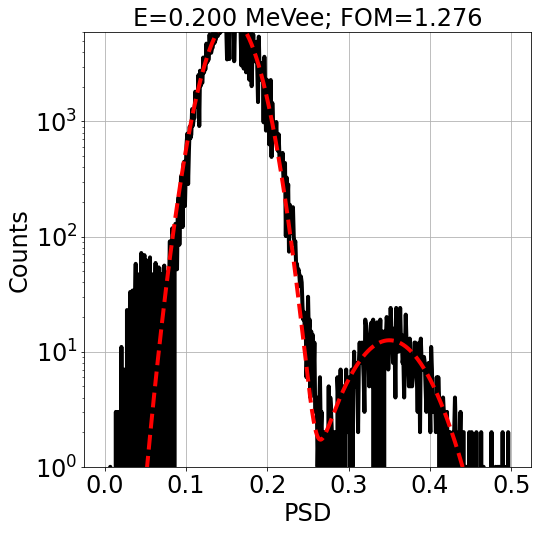

In [28]:
# Graph FOM threshold slice
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(psd_bin_lbs, Z.T[:,slice_idx], "k", lw=4)
params = tuple(df.iloc[slice_idx,1:7])
ax.plot(psd_bin_lbs, bimodal(psd_bin_lbs, *params), "r--", lw=4)
ax.set_ylim(1, 6e3)
ax.grid()
ax.set_yscale("log")
ax.set_ylabel("Counts", fontsize=fontsize)
ax.set_xlabel("PSD", fontsize=fontsize)
ax.set_title(f"E={xe[slice_idx]:.3f} MeVee; FOM={fom:.3f}", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.tick_params(axis='both', which='minor', labelsize=fontsize)

<IPython.core.display.Javascript object>


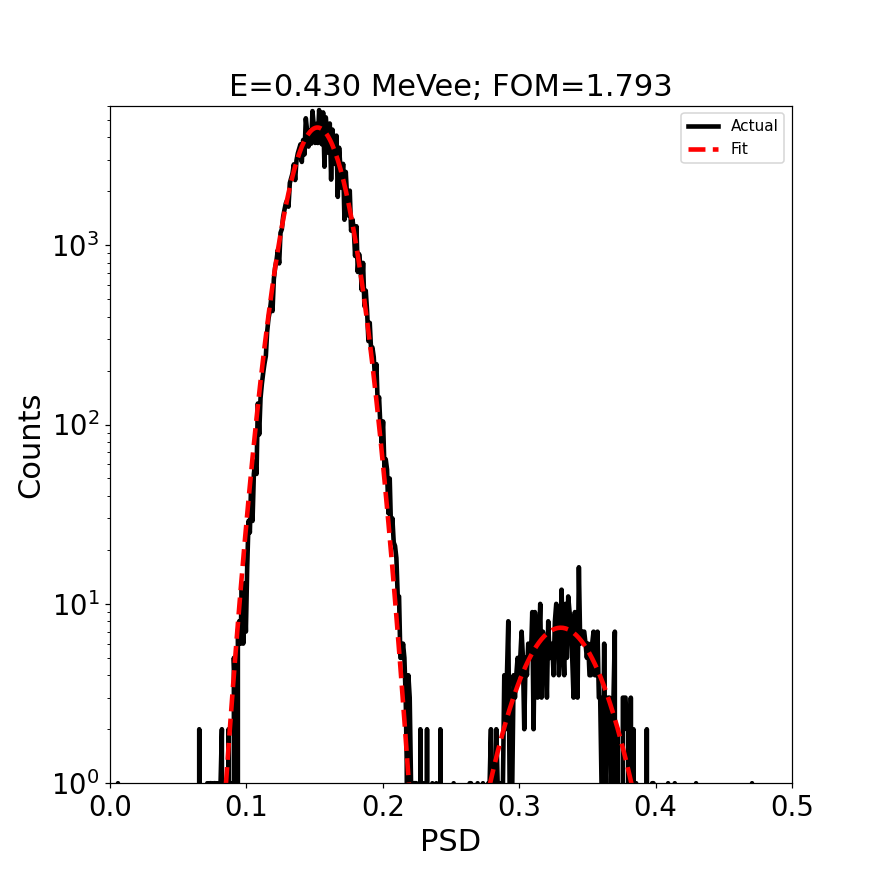

In [26]:
# Show histogram scan animation (optional, but useful for checking goodness of fit)
%matplotlib notebook
from matplotlib.animation import FuncAnimation

ylim = (1, 6e3)  # Y axis limits used (change to match data set used)
anim_fs = 20  # Font size used (axis labels and title)
anim_ls = 18  # Line size used for axis ticks
anim_lw = 3  # Line width used for line plotting
frames = range(0,120)  # slices to view
interval = 60  # delay between frames in milliseconds (lower = faster)

fig = plt.figure(figsize=(8,8))
ax = plt.axes(xlim=(0, 0.5), ylim=ylim, yscale="log")
line1, = ax.plot([], [], 'k', lw=anim_lw, label='Actual')
line2, = ax.plot([], [], 'r--', lw=anim_lw, label='Fit')

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    ax.legend()
    ax.set_xlabel('PSD', fontsize=anim_fs)
    ax.set_ylabel('Counts', fontsize=anim_fs)
    ax.tick_params(axis='both', which='major', labelsize=anim_ls)
    ax.tick_params(axis='both', which='minor', labelsize=anim_ls)
    return line1, line2

def animate(i):
    x = psd_bin_lbs
    y = Z.T[:,i]
    line1.set_data(x, y)
    params = tuple(df.iloc[i,1:7])
    fom = df['fom'][i]
    y = bimodal(x, *params)
    line2.set_data(x, y)
    ax.set_title(f"E={xe[i]:.3f} MeVee; FOM={fom:.3f}", fontsize=anim_fs)

    return line1, line2

anim = FuncAnimation(fig, animate, init_func=init, frames=frames, interval=interval, blit=True)

# anim.save('../notebooks/images/FOM_graph.gif', writer='pillow')

In [27]:
# Stops interactive graph views. Allows later static graphs, but stops animation
%matplotlib inline

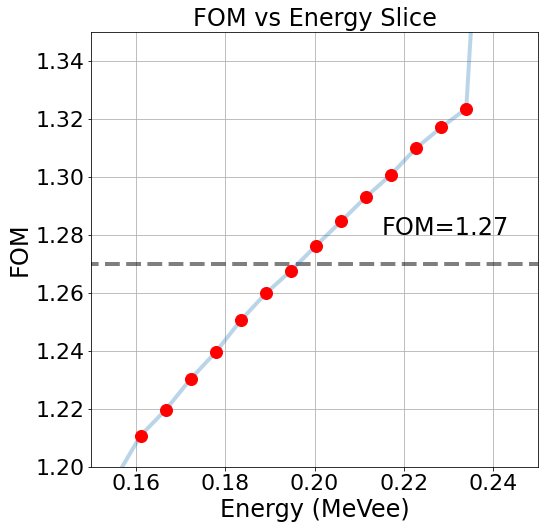

In [29]:
ylim = 1.2, 1.35  # Plot view limits on Y axis
xlim = 0.15, 0.25  # Plot view limits on X axis

fig, ax = plt.subplots(figsize=(8,8))


ax.hlines(1.27, 0, 1.25, color='k', linestyle='--', alpha=0.5, lw=4)

ax.plot(
    xe[start_scan_idx:end_scan_idx], 
    df['fom'][start_scan_idx:end_scan_idx], 
    "-",
    alpha=0.3,
    lw=4
)

ax.plot(
    xe[start_scan_idx:end_scan_idx], 
    df['fom'][start_scan_idx:end_scan_idx], 
    "ro",
    markersize=12,
)

ax.text(*(0.215, 1.27 + 0.01), "FOM=1.27", fontsize=fontsize)

ax.set_ylim(*ylim)
ax.set_xlim(*xlim)
ax.set_title("FOM vs Energy Slice", fontsize=fontsize)
ax.set_ylabel("FOM", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)

# ax.legend(fontsize=fontsize)
ax.grid()
# ax.set_yticks(np.arange(1,2.25,0.25))
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)

In [30]:
# Interpolate between slices near FOM threshold to find best lower energy cutoff
fom_idx = slice_idx

fom_fit = interp1d(df["fom"][fom_idx-1:fom_idx+1], xe[fom_idx-1:fom_idx+1], kind="linear")
L0 = fom_fit(1.27)
f"FOM ENERGY CUTOFF = {L0:.4f} MeVee"

'FOM ENERGY CUTOFF = 0.1963 MeVee'

# Counting Windows

In [312]:
# Window fitting function definition

window_adj_offset = 0

def classify(
    psd_report: pd.DataFrame, 
    lb_fit_fn: Callable[[np.ndarray], np.ndarray], 
    ub_fit_fn: Callable[[np.ndarray], np.ndarray], 
    label: str, 
    le_cutoff: float = L0
) -> pd.DataFrame:
    """Classify signals as neutron or non-neutron for a given count window
    
    Parameters
    ----------
    psd_report: DataFrame
        DataFrame containing signal PSD data. 
        It must have the "tail / total" (for PSD value) and "CALIB_ENERGY" (for calibrated energy) columns.
    lb_fit_fn: Callable[[ndarray], ndarray]
        A function describing the window's lower bounds
    ub_fit_fn: Callable[[ndarray], ndarray]
        A function describing the window's upper bounds
    label: str
        column label to use for signal classification results
    le_cutoff: float, default L0 (previously determined lower energy cutoff)
        Lower energy cutoff (AKA the left boundary of the neutron window)
        
    Returns
    -------
    psd_report: DataFrame
        Original DataFrame with new column for neutron classification
    """
    psd_report[label] = psd_report["tail / total"].between(
        lb_fit_fn(psd_report["CALIB_ENERGY"].astype(float)) + 
        window_adj_offset, ub_fit_fn(psd_report["CALIB_ENERGY"].astype(float))
    ) & (psd_report["CALIB_ENERGY"] >= le_cutoff)
    
    return psd_report

def plot_classification(
    neutrons, 
    gammas, 
    lb_fit,
    ub_fit,
    max_energy,
    FOM_cutoff,
    n_neutrons,
    label_a = "Neutrons",
    label_b = "Non-Neutrons",
):
    fig, ax = plt.subplots(figsize=(10,10))
    ax.scatter(gammas["CALIB_ENERGY"], gammas["tail / total"], s=2, label=label_b)
    ax.scatter(neutrons["CALIB_ENERGY"], neutrons["tail / total"], s=2, label=label_a)

    energy_space = np.linspace(xe[0], max_energy + 0.5, 200)

    ax.plot(energy_space, lb_fit(energy_space), 'r--')
    ax.plot(energy_space, ub_fit(energy_space), 'r--')
    
    ax.vlines(all_slice_xs[0], lb_fit(all_slice_xs[0]), ub_fit(all_slice_xs[0]), 'r', ls='--')

    ax.vlines(FOM_cutoff, lb_fit(FOM_cutoff), ub_fit(FOM_cutoff), 'r', ls="--")

    ax.set_title(f"Counts = {n_neutrons}", fontsize=fontsize)
    ax.set_ylim(0, 0.55)
    ax.set_xlim(0, max_energy + .05)
    
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.tick_params(axis='both', which='minor', labelsize=22)
    
    ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
    ax.set_ylabel("PSD", fontsize=fontsize)
    ax.legend(fontsize=fontsize)
    return fig, ax

In [313]:
all_slice_xs = xe[:end_scan_idx]

## NASA  


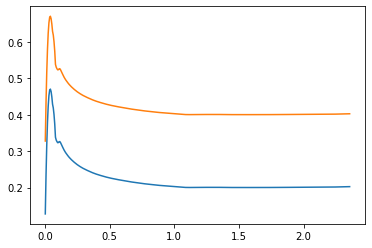

In [314]:
window_offset = 0.2
sigma = 5

neutron_lb = savgol_filter(df["mu1"] + sigma * df["sigma1"], window_length=21, polyorder=3)
neutron_lb_fit = interp1d(all_slice_xs, neutron_lb, fill_value=(neutron_lb[0], neutron_lb[-1]), bounds_error=False)

def neutron_ub_fit(x):
    return neutron_lb_fit(x) + window_offset

plt.plot(all_slice_xs, neutron_lb_fit(all_slice_xs))
plt.plot(all_slice_xs, neutron_ub_fit(all_slice_xs))

In [315]:
psd_report = classify(psd_report, neutron_lb_fit, neutron_ub_fit, "NASA",le_cutoff=L0)

In [35]:
del graph_sample
graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

(<Figure size 720x720 with 1 Axes>,
 <AxesSubplot:title={'center':'Counts = 65465'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

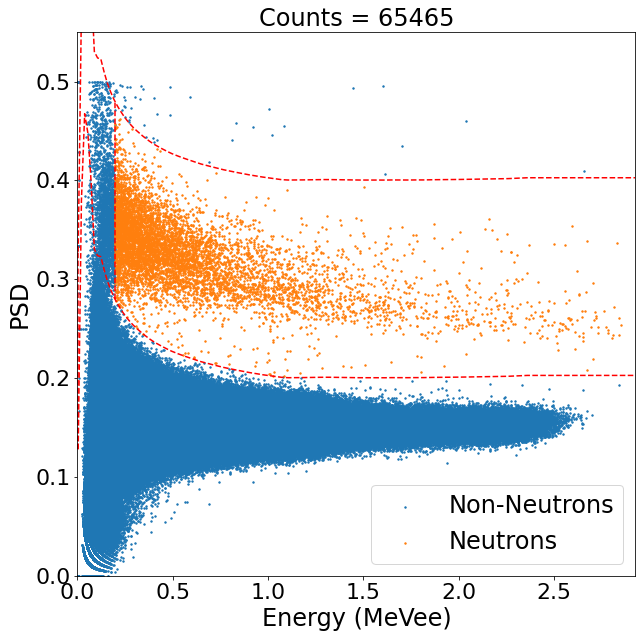

In [316]:
plot_classification(
    graph_sample[graph_sample["NASA"]], 
    graph_sample[~graph_sample["NASA"]], 
    neutron_lb_fit, 
    neutron_ub_fit, 
    psd_report["CALIB_ENERGY"].max(), 
    L0,
    psd_report[psd_report["NASA"]].shape[0]
)


# plt.plot(all_slice_xs, df["mu2"])
# plt.plot(all_slice_xs, df["mu1"] + 4 * df["sigma1"])
# plt.xlim(0.2,0.4)
# plt.ylim(0.3, 0.5)

## Straight Edge

In [38]:
straight_edge_sigma = 4

slice_start = fom_idx
neutron_straight_lb = df["mu2"][slice_start:] - straight_edge_sigma * df["sigma2"][slice_start:]
neutron_straight_lb_fit = linregress(all_slice_xs[slice_start:], neutron_straight_lb)

In [83]:
f"Lower PSD Cutoff = {neutron_straight_lb_fit.intercept:.4f}"

'Lower PSD Cutoff = 0.2189'

In [84]:
def straight_lb(x):
    return neutron_straight_lb_fit.intercept * np.ones_like(x)

def straight_ub(x):
    return 0.5 * np.ones_like(x)

In [91]:
psd_report = classify(psd_report, straight_lb, straight_ub, "straight", le_cutoff=L0+0.2)

In [92]:
del graph_sample
graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

(<Figure size 720x720 with 1 Axes>,
 <AxesSubplot:title={'center':'Counts = 37276'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

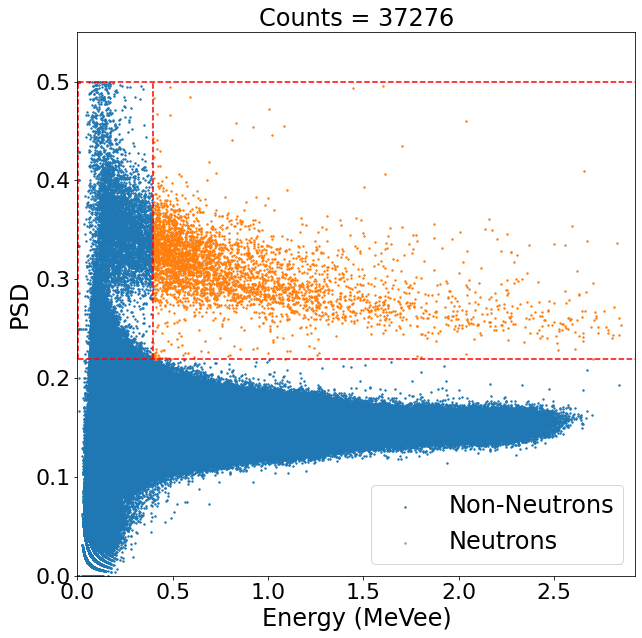

In [93]:
plot_classification(
    graph_sample[graph_sample["straight"]], 
    graph_sample[~graph_sample["straight"]], 
    straight_lb, 
    straight_ub, 
    psd_report["CALIB_ENERGY"].max(), 
    L0+0.2,
    psd_report[psd_report["straight"]].shape[0],
    label_a="Neutrons",
    label_b="Non-Neutrons"
)

## Gamma Cover

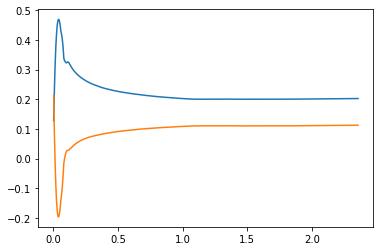

In [94]:
window_offset = 0.2
sigma = 4

gamma_lb = savgol_filter(df["mu1"] - sigma * df["sigma1"], window_length=21, polyorder=3)
gamma_lb_fit = interp1d(all_slice_xs, gamma_lb, fill_value=(gamma_lb[0], gamma_lb[-1]), bounds_error=False)

plt.plot(all_slice_xs, neutron_lb_fit(all_slice_xs))
plt.plot(all_slice_xs, gamma_lb_fit(all_slice_xs))

In [95]:
psd_report = classify(psd_report, gamma_lb_fit, neutron_lb_fit, "gamma_cover")

In [96]:
del graph_sample
graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

(<Figure size 720x720 with 1 Axes>,
 <AxesSubplot:title={'center':'Counts = 30266024'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

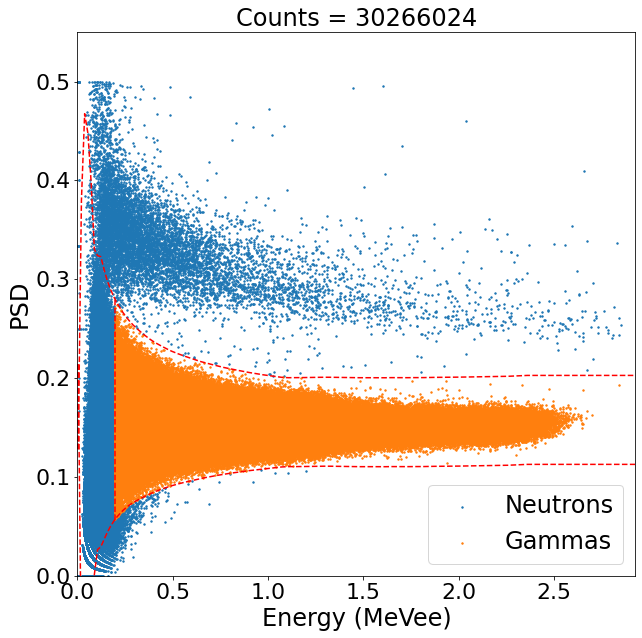

In [97]:
plot_classification(
    graph_sample[graph_sample["gamma_cover"]], 
    graph_sample[~graph_sample["gamma_cover"]], 
    gamma_lb_fit, 
    neutron_lb_fit, 
    psd_report["CALIB_ENERGY"].max(), 
    L0,
    psd_report[psd_report["gamma_cover"]].shape[0],
    "Gammas",
    "Neutrons"
)

## Neutron Cover

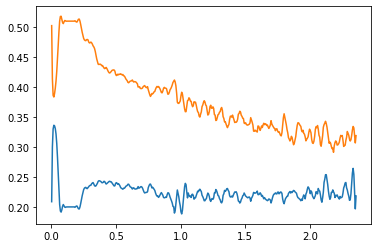

In [72]:
window_offset = 0.2
sigma = 4


lb_adjust = 0.01

nn_lb = savgol_filter(df["mu2"] - sigma * df["sigma2"], window_length=21, polyorder=7) + lb_adjust
nn_lb_fit = interp1d(all_slice_xs, nn_lb, fill_value=(nn_lb[0], nn_lb[-1]), bounds_error=False)

nn_ub = savgol_filter(df["mu2"] + sigma * df["sigma2"], window_length=21, polyorder=7)
nn_ub_fit = interp1d(all_slice_xs, nn_ub, fill_value=(nn_ub[0], nn_ub[-1]), bounds_error=False)

plt.plot(all_slice_xs, nn_lb_fit(all_slice_xs))
plt.plot(all_slice_xs, nn_ub_fit(all_slice_xs))

In [73]:
le_cutoff = L0 + 0.15
psd_report = classify(psd_report, nn_lb_fit, nn_ub_fit, "neutron_cover", le_cutoff)

In [74]:
del graph_sample
graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

(<Figure size 720x720 with 1 Axes>,
 <AxesSubplot:title={'center':'Counts = 41603'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

C:\Users\User\Documents\GitHub\thunderbird_psd\.venv\lib\site-packages\IPython\core\events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\User\Documents\GitHub\thunderbird_psd\.venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


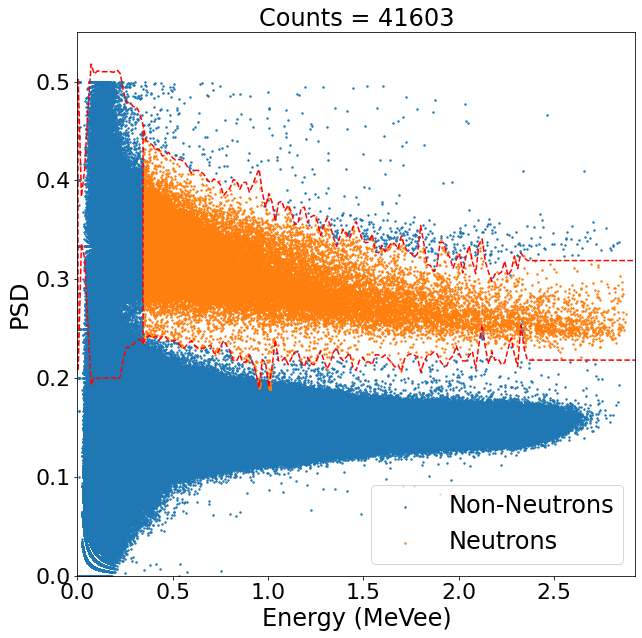

In [75]:
plot_classification(
    psd_report[psd_report["neutron_cover"]], 
    psd_report[~psd_report["neutron_cover"]], 
    nn_lb_fit, 
    nn_ub_fit, 
    psd_report["CALIB_ENERGY"].max(), 
    le_cutoff,
    psd_report[psd_report["neutron_cover"]].shape[0],
)

# CPS

In [290]:
def counts_over_time_histogram(df, dwell_time, total_time):
    n_bins = int(total_time / dwell_time)   
    counts, bins = np.histogram(df, n_bins)
    return counts[1:], bins[1:]


def plot_histogram(
    bins, 
    counts,
    labels,
    style = "points",
    **kwargs
):
    "Style options: `points`, `stairs`"
    fig, ax = plt.subplots(dpi=140)
    
    for bin, count, label in zip(bins, counts, labels):
        if style == "points":
            ax.plot(bin[:-1], count, "o", label=label, **kwargs)
        
        elif style == "stairs":
            ax.stairs(count, bin, label=label, lw=4, **kwargs)
    
    ax.legend()
    return fig, ax

def omega(a, d):
    return 2*np.pi*(1-(d/np.sqrt(d**2+a**2)))

In [323]:
dwell_time = 60 * 14 # s

total_time = psd_report["TIMETAG"].max() * 1e-12 # s
f"Total time = {total_time:.3f}s"

'Total time = 408917.790s'

## NASA Style

In [171]:
dwell_time = 60*5 # s

In [291]:
neutron_time_counts, neutron_time_bins = counts_over_time_histogram(
    psd_report[psd_report["NASA"]]["TIMETAG"] * 1e-12/3600, dwell_time, total_time
)

gamma_time_counts, gamma_time_bins = counts_over_time_histogram(
    psd_report[~psd_report["NASA"]]["TIMETAG"]  * 1e-12/3600, dwell_time, total_time
)

Text(0.5, 0, 'Time (s)')

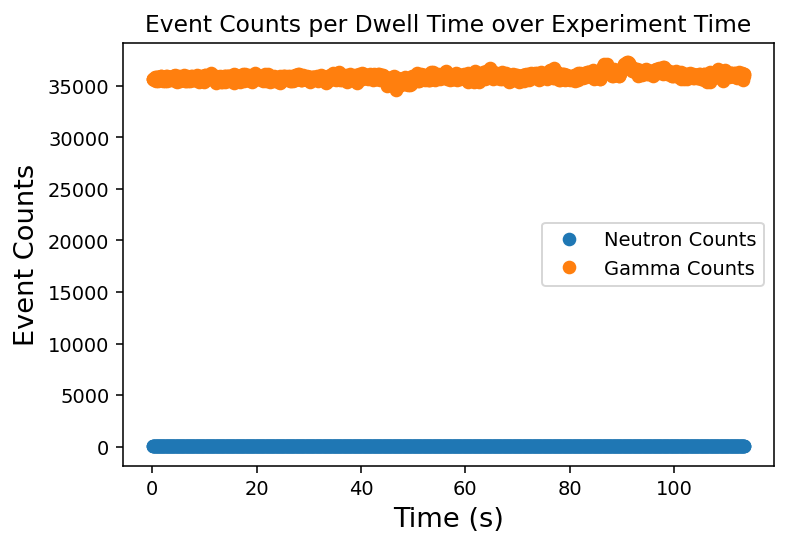

In [292]:
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_counts, gamma_time_counts],
    labels=["Neutron Counts", "Gamma Counts"]
)

ax.set_title("Event Counts per Dwell Time over Experiment Time")
ax.set_ylabel("Event Counts", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [305]:
neutron_time_cps = neutron_time_counts / dwell_time
gamma_time_cps = gamma_time_counts / dwell_time

In [325]:
neutron_mean = np.average(neutron_time_cps)
neutron_sigma = np.sqrt(65465)/total_time
neutron_sigma_stat = stat.stdev(neutron_time_cps)
print(f"Mean: {neutron_mean}\nSigma: {neutron_sigma}")
print(f"Standard Deviation: {neutron_sigma_stat}")

Mean: 0.16012481644640236
Sigma: 0.0006257034951896332
Standard Deviation: 0.025385442480298927


Text(0.5, 0, 'Time (hrs)')

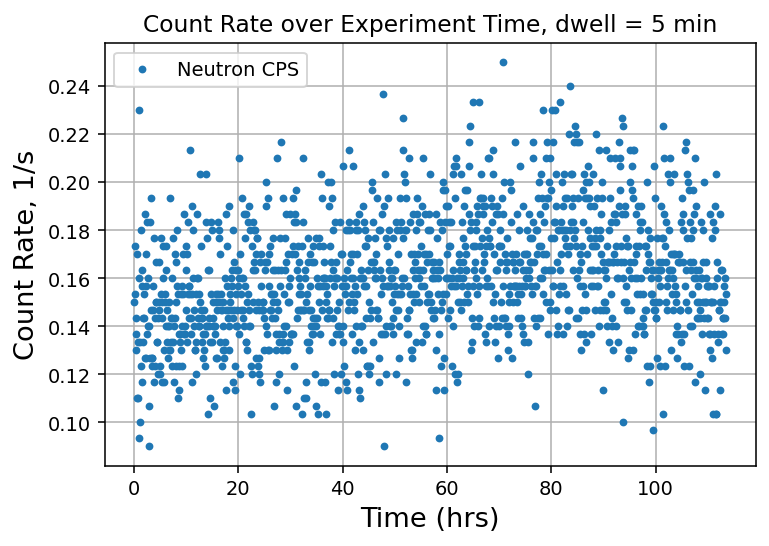

In [294]:
fig, ax = plot_histogram(
    [neutron_time_bins],#, gamma_time_bins],
    [neutron_time_cps],#, gamma_time_cps],
    labels=["Neutron CPS", "Non-Neutron CPS"],
    markersize =3,
)



#ax.set_yscale('log')
ax.grid()
ax.set_title("Count Rate over Experiment Time, dwell = 5 min")
ax.set_ylabel("Count Rate, 1/s", fontsize=14)
ax.set_xlabel("Time (hrs)", fontsize=14)
#ax.set_xlim(0.075, 0.25)

Text(0.5, 0, 'Time (hrs)')

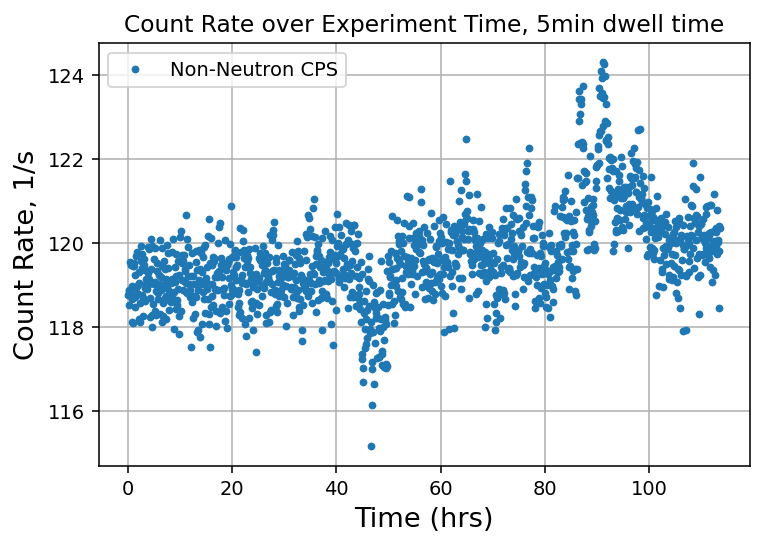

In [296]:

fig, ax = plot_histogram(
    [gamma_time_bins],
    [gamma_time_cps],
    labels=["Non-Neutron CPS"],
    markersize=3,
)

#ax.set_yscale('log')
ax.grid()
ax.set_title("Count Rate over Experiment Time, 5min dwell time")
ax.set_ylabel("Count Rate, 1/s", fontsize=14)
ax.set_xlabel("Time (hrs)", fontsize=14)
#ax.set_xlim(0.075, 0.25)

In [88]:
cps_n_bins = 450

neutron_cps_counts, neutron_cps_bins = np.histogram(neutron_time_cps, cps_n_bins)
gamma_cps_counts, gamma_cps_bins = np.histogram(gamma_time_cps, cps_n_bins)


f"CPS Bin Width: {gamma_cps_bins[2] - gamma_cps_bins[1]:.4f}s"

'CPS Bin Width: 0.0157s'

In [302]:
neutron_mean = np.average(neutron_time_cps)
neutron_sigma = np.sqrt(neutron_mean / len(neutron_time_cps))
print(f"Mean: {neutron_mean}\nSigma: {neutron_sigma}")
print(neutron_time_counts)

Mean: 0.16012481644640236
Sigma: 0.01084278306190165
[45 52 46 ... 48 39 46]


In [89]:
psd_report[psd_report["NASA"]].shape[0] / total_time * 60 * 56

537.9135006958542

(0.075, 0.25)

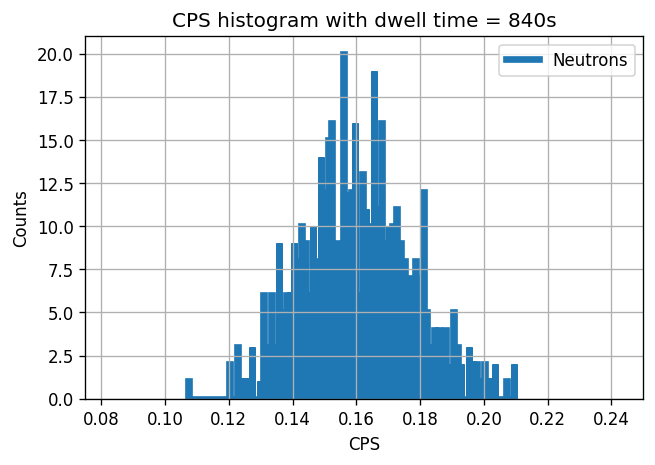

In [90]:
fig, ax = plot_histogram(
    [neutron_cps_bins, gamma_cps_bins],
    [neutron_cps_counts, gamma_cps_counts],
    style="stairs",
    labels=["Neutrons"]
)


ax.grid()
ax.set_xlabel("CPS")
ax.set_ylabel("Counts")
ax.set_title(f"CPS histogram with dwell time = {dwell_time}s")
ax.set_xlim(0.075, 0.25)

## Straight Edge

In [111]:
dwell_time = 1 #s

neutron_time_counts, neutron_time_bins = counts_over_time_histogram(
    psd_report[psd_report["straight"]]["TIMETAG"] * 1e-12, dwell_time, total_time
)

gamma_time_counts, gamma_time_bins = counts_over_time_histogram(
    psd_report[~psd_report["straight"]]["TIMETAG"]  * 1e-12, dwell_time, total_time
)

Text(0.5, 0, 'Time (s)')

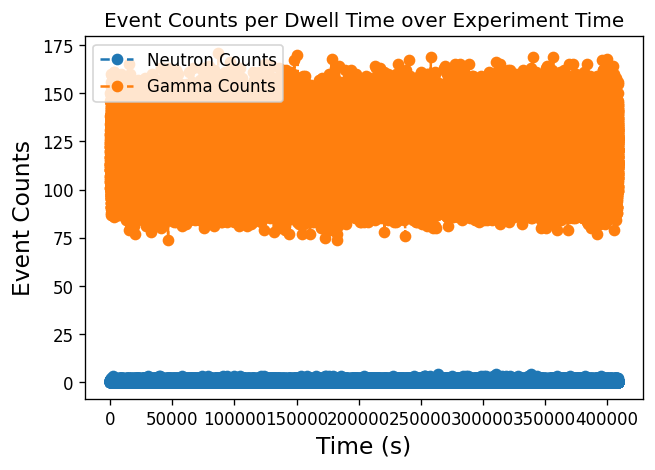

In [112]:
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_counts, gamma_time_counts],
    labels=["Neutron Counts", "Gamma Counts"]
)

ax.set_title("Event Counts per Dwell Time over Experiment Time")
ax.set_ylabel("Event Counts", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [113]:
neutron_time_cps = neutron_time_counts / dwell_time
gamma_time_cps = gamma_time_counts / dwell_time

Text(0.5, 0, 'Time (s)')

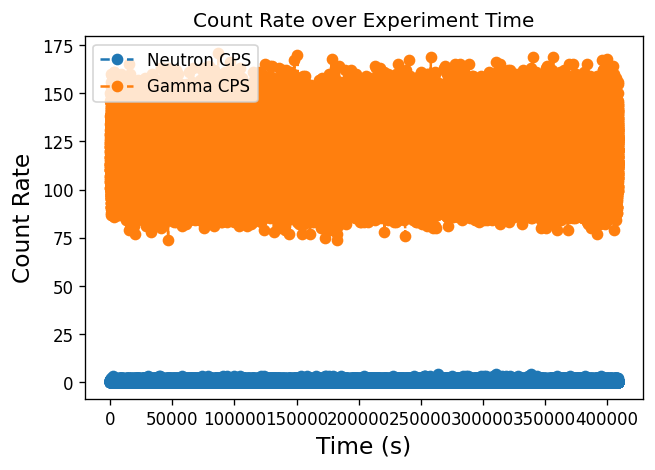

In [114]:
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_cps, gamma_time_cps],
    labels=["Neutron CPS", "Gamma CPS"]
)

ax.set_title("Count Rate over Experiment Time")
ax.set_ylabel("Count Rate", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [115]:
cps_n_bins = 124

neutron_cps_counts, neutron_cps_bins = np.histogram(neutron_time_cps, cps_n_bins)
gamma_cps_counts, gamma_cps_bins = np.histogram(gamma_time_cps, cps_n_bins)


f"CPS Bin Width: {gamma_cps_bins[2] - gamma_cps_bins[1]:.4f}s"

'CPS Bin Width: 0.7823s'

Text(0.5, 1.0, 'CPS histogram with dwell Time = 1s')

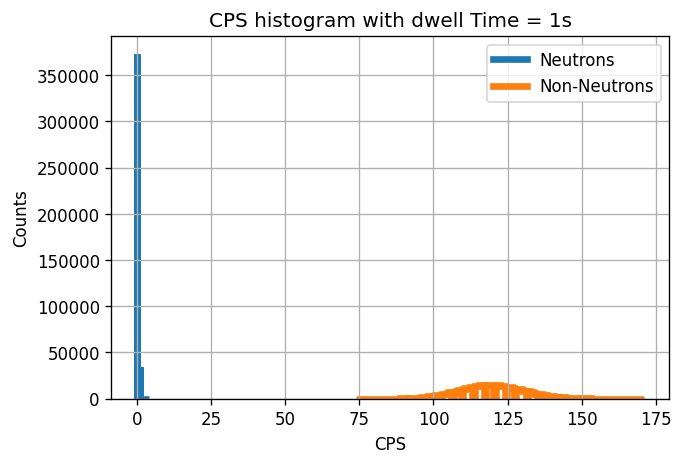

In [117]:
fig, ax = plot_histogram(
    [neutron_cps_bins, gamma_cps_bins],
    [neutron_cps_counts, gamma_cps_counts],
    style="stairs",
    labels=["Neutrons", "Non-Neutrons"]
)


ax.grid()
# ax.set_ylim(0, 40)
# ax.set_xlim(100, 300)
ax.set_xlabel("CPS")
ax.set_ylabel("Counts")
ax.set_title(f"CPS histogram with dwell Time = {dwell_time}s")

# Covers

In [89]:
dwell_time = 1 #s

neutron_time_counts, neutron_time_bins = counts_over_time_histogram(
    psd_report[psd_report["neutron_cover"]]["TIMETAG"] * 1e-12, dwell_time, total_time
)

gamma_time_counts, gamma_time_bins = counts_over_time_histogram(
    psd_report[~psd_report["gamma_cover"]]["TIMETAG"]  * 1e-12, dwell_time, total_time
)

Text(0.5, 0, 'Time (s)')

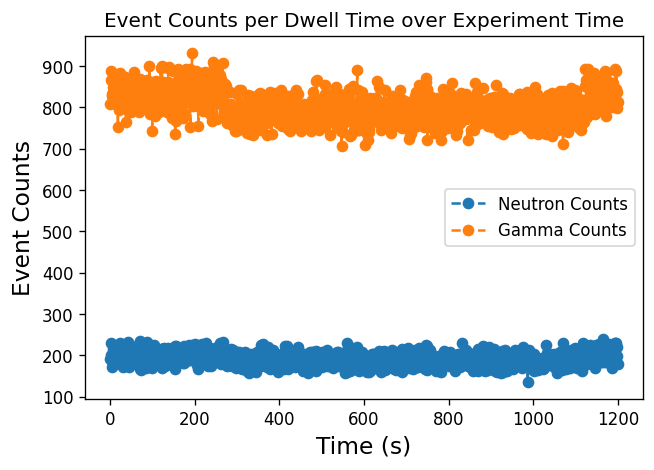

In [90]:
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_counts, gamma_time_counts],
    labels=["Neutron Counts", "Gamma Counts"]
)

ax.set_title("Event Counts per Dwell Time over Experiment Time")
ax.set_ylabel("Event Counts", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [91]:
neutron_time_cps = neutron_time_counts / dwell_time
gamma_time_cps = gamma_time_counts / dwell_time

Text(0.5, 0, 'Time (s)')

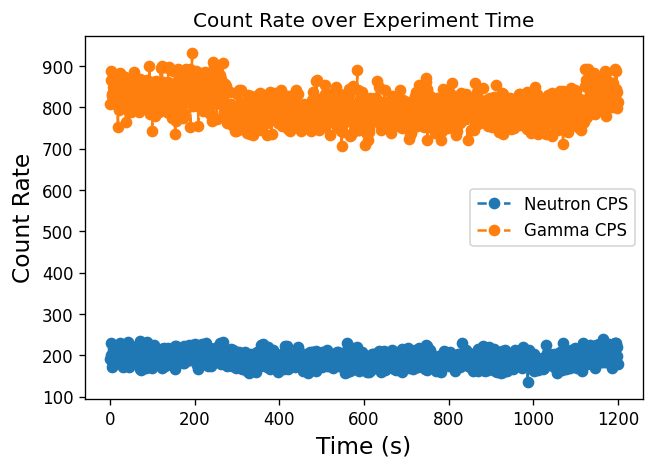

In [92]:
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_cps, gamma_time_cps],
    labels=["Neutron CPS", "Gamma CPS"]
)

ax.set_title("Count Rate over Experiment Time")
ax.set_ylabel("Count Rate", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [93]:
cps_n_bins = 124

neutron_cps_counts, neutron_cps_bins = np.histogram(neutron_time_cps, cps_n_bins)
gamma_cps_counts, gamma_cps_bins = np.histogram(gamma_time_cps, cps_n_bins)


f"CPS Bin Width: {gamma_cps_bins[2] - gamma_cps_bins[1]:.4f}s"

'CPS Bin Width: 1.8145s'

Text(0.5, 1.0, 'CPS histogram with dwell Time =1s')

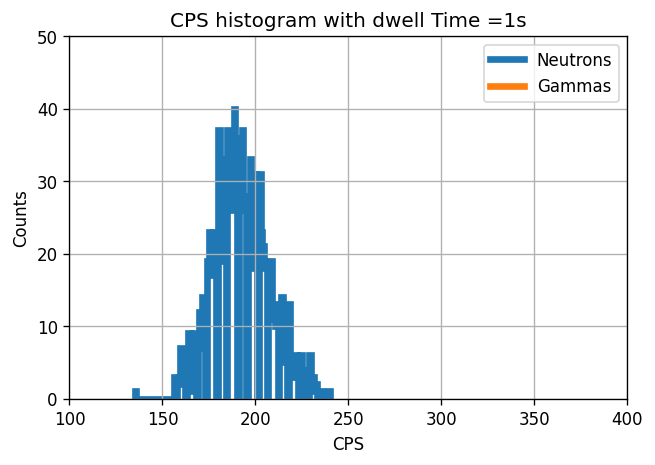

In [94]:
fig, ax = plot_histogram(
    [neutron_cps_bins, gamma_cps_bins],
    [neutron_cps_counts, gamma_cps_counts],
    style="stairs",
    labels=["Neutrons", "Gammas"]
)


ax.grid()
ax.set_xlim(100,400)
ax.set_ylim(0,50)
ax.set_xlabel("CPS")
ax.set_ylabel("Counts")
ax.set_title(f"CPS histogram with dwell Time ={dwell_time}s")